## RESUME/CANDIDATE SCREENING SYSTEM

## Project Objective
This project aims to build an automated resume screening system that extracts skills from resumes, compares them with a job description, ranks candidates based on similarity scores, and identifies skill gaps.

## Loading the Dataset

In [46]:
import pandas as pd

df = pd.read_csv("Resume.csv") 

## Displaying the dimensions of dataset

In [47]:
print(df.shape)

(2484, 4)


## Displaying the features present in dataset

In [48]:
print(df.columns.tolist())

['ID', 'Resume_str', 'Resume_html', 'Category']


## Displaying first 5 rows

In [49]:
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


## Displaying last 5 rows

In [50]:
df.tail()

,ID,Resume_str,Resume_html,Category
2479,99416532,RANK: SGT/E-5 NON- COMMISSIONED OFFIC...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2480,24589765,"GOVERNMENT RELATIONS, COMMUNICATIONS ...","<div class=""fontsize fontface vmargins hmargin...",AVIATION
2481,31605080,GEEK SQUAD AGENT Professional...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2482,21190805,PROGRAM DIRECTOR / OFFICE MANAGER ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION
2483,37473139,STOREKEEPER II Professional Sum...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION


## Dataset Information

In [51]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB


In [52]:
df.describe(include='all')

,ID,Resume_str,Resume_html,Category
count,2.484000e+03,2484,2484,2484
unique,NaN,2482,2482,24
top,NaN,STOREKEEPER II Professional Sum...,"<div class=""fontsize fontface vmargins hmargin...",INFORMATION-TECHNOLOGY
freq,NaN,2,2,120
mean,3.182616e+07,NaN,NaN,NaN
std,2.145735e+07,NaN,NaN,NaN
min,3.547447e+06,NaN,NaN,NaN
25%,1.754430e+07,NaN,NaN,NaN
50%,2.521031e+07,NaN,NaN,NaN
75%,3.611444e+07,NaN,NaN,NaN


## Missing Value Analysis

In [53]:
df.isnull().sum()

ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64

## Resume Category Distribution

In [54]:
df['Category'].value_counts()

Category
INFORMATION-TECHNOLOGY    120
BUSINESS-DEVELOPMENT      120
FINANCE                   118
ADVOCATE                  118
ACCOUNTANT                118
ENGINEERING               118
CHEF                      118
AVIATION                  117
FITNESS                   117
SALES                     116
BANKING                   115
HEALTHCARE                115
CONSULTANT                115
CONSTRUCTION              112
PUBLIC-RELATIONS          111
HR                        110
DESIGNER                  107
ARTS                      103
TEACHER                   102
APPAREL                    97
DIGITAL-MEDIA              96
AGRICULTURE                63
AUTOMOBILE                 36
BPO                        22
Name: count, dtype: int64

## Visualization of Resume category Distribution
### 
The dataset contains resumes from multiple professional domains. Some categories contain more resumes than others, indicating variation in representation across job roles.

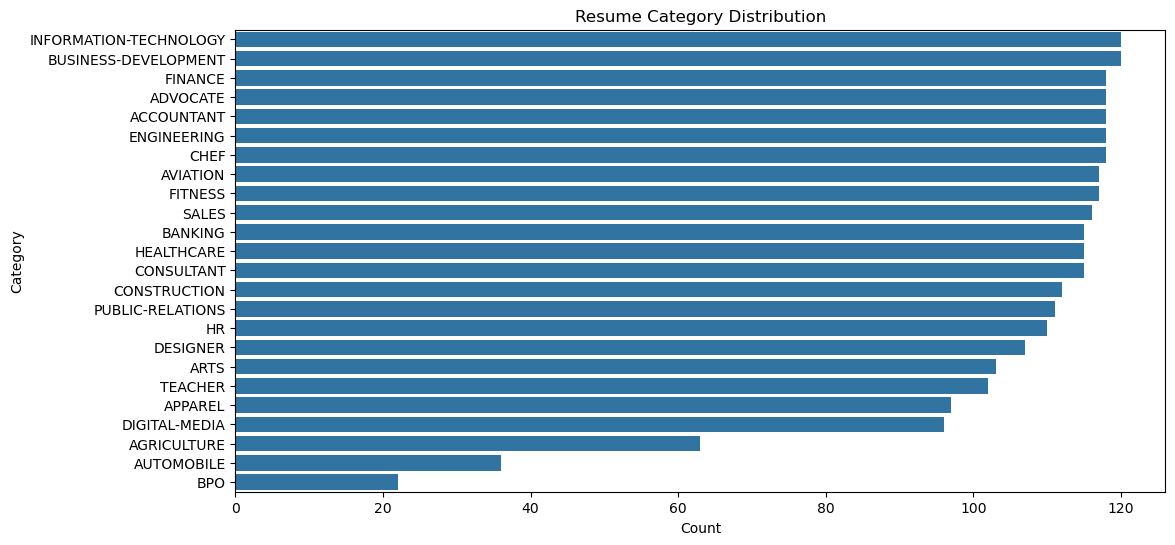

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.countplot(
    y='Category',
    data=df,
    order=df['Category'].value_counts().index
)

plt.title('Resume Category Distribution')
plt.xlabel('Count')
plt.ylabel('Category')

plt.show()

## Text Preprocessing

In [56]:
import nltk
import re
import string

from nltk.corpus import stopwords

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saigi\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [57]:
stop_words = set(stopwords.words('english'))

## Text Cleaning Function

In [58]:
def clean_resume(text):

    text = str(text).lower()

    text = re.sub(r'\d+', '', text)

    text = text.translate(
        str.maketrans(
            '',
            '',
            string.punctuation
        )
    )

    words = text.split()

    words = [
        word
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

## Applying Text Cleaning function

In [59]:
df['Clean_Resume'] = df['Resume_str'].apply(clean_resume)

In [60]:
df[['Resume_str','Clean_Resume']].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administratormarketing associate hr adminis...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary years experience recruitin...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven dynamic...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


## Skill Extraction

In [91]:
skills = [
'python',
'sql',
'machine learning',
'deep learning',
'tensorflow',
'keras',
'pandas',
'numpy',
'scikit-learn',
'power bi',
'tableau',
'excel',
'statistics',
'data analysis',
'data visualization',
'java',
'c++',
'aws',
'azure',
'docker',
'git',
'html',
'css',
'javascript',
'react',
'nodejs',
'mysql',
'mongodb',
'linux'
]

In [62]:
def extract_skills(text):

    text = text.lower()

    found_skills = []

    for skill in skills:

        if skill in text:
            found_skills.append(skill)

    return found_skills

## Extracting Skills from Resumes

In [63]:
df['Skills'] = df['Clean_Resume'].apply(extract_skills)

In [64]:
df[['Category','Skills']].head()

,Category,Skills
0,HR,"[statistics, data analysis, aws]"
1,HR,[git]
2,HR,[excel]
3,HR,[excel]
4,HR,"[excel, aws]"


## Most Common Skills Found in Resumes

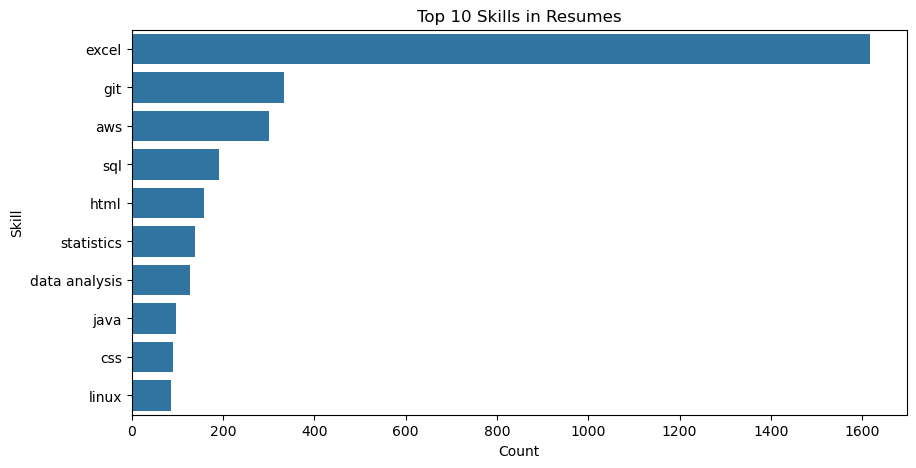

In [65]:
from collections import Counter

all_skills = []

for skill_list in df['Skills']:
    all_skills.extend(skill_list)

skill_counts = Counter(all_skills)

skills_df = pd.DataFrame(
    skill_counts.items(),
    columns=['Skill','Count']
)

skills_df = skills_df.sort_values(
    by='Count',
    ascending=False
).head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    data=skills_df,
    x='Count',
    y='Skill'
)

plt.title('Top 10 Skills in Resumes')

plt.show()

## creating a Job description

In [66]:
job_description = """
Data Scientist

Required Skills:

Python
Machine Learning
SQL
Statistics
Data Analysis
Data Visualization
Pandas
NumPy
Scikit-Learn
Power BI
"""

# Flatten newlines so multi-word skills like 'machine learning' are found correctly
job_description_flat = job_description.replace('\n', ' ').lower()

print(job_description)



Data Scientist

Required Skills:

Python
Machine Learning
SQL
Statistics
Data Analysis
Data Visualization
Pandas
NumPy
Scikit-Learn
Power BI



## Extracting Skills from the Job Description

In [67]:
# Extract skills from the flattened JD text to avoid newline boundary misses
jd_skills = extract_skills(job_description_flat)

print(jd_skills)


['python', 'sql', 'machine learning', 'pandas', 'numpy', 'scikit-learn', 'power bi', 'statistics', 'data analysis', 'data visualization']


## Resume Matching Using TF-IDF

In [68]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [69]:
# Build corpus from resumes only — JD must NOT be included in TF-IDF fit
# to prevent data leakage (JD words inflating similarity scores)
corpus = df['Clean_Resume'].tolist()


## Transforming Text into Numerical Features

In [70]:
tfidf = TfidfVectorizer(
    max_features=5000
)

# Fit ONLY on resumes, then transform resumes and JD separately
resume_matrix = tfidf.fit_transform(corpus)

# Transform the job description using the same vocabulary
jd_matrix = tfidf.transform([job_description_flat])

# Combine for downstream compatibility (resumes first, JD last)
import scipy.sparse as sp
tfidf_matrix = sp.vstack([resume_matrix, jd_matrix])

print('Resume matrix shape:', resume_matrix.shape)
print('TF-IDF matrix shape (resumes + JD):', tfidf_matrix.shape)


In [71]:
print(tfidf_matrix.shape)

(2485, 5000)


In [72]:
from sklearn.metrics.pairwise import cosine_similarity

In [73]:
resume_vectors = tfidf_matrix[:-1]
job_vector = tfidf_matrix[-1]

## Calculating Resume Similarity Scores

In [74]:
similarity_scores = cosine_similarity(
    resume_vectors,
    job_vector
)

In [75]:
print(similarity_scores.shape)

(2484, 1)


In [76]:
df['Match_Score'] = similarity_scores * 100

## Distribution of Resume Match Scores

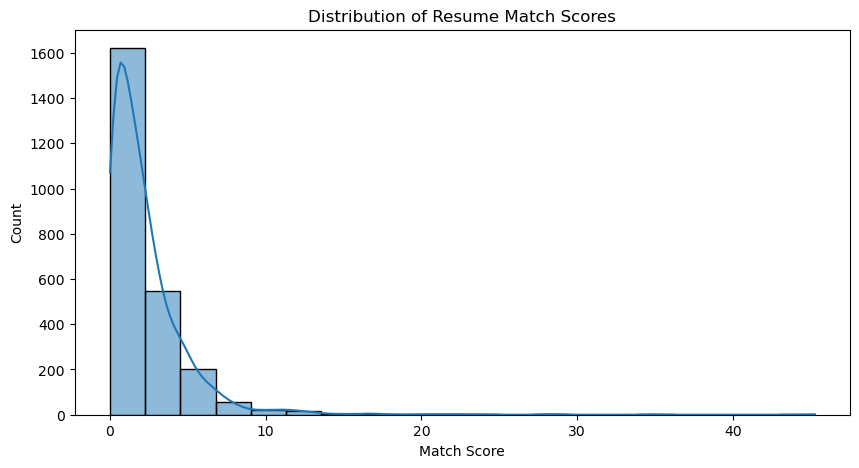

In [77]:
plt.figure(figsize=(10,5))

sns.histplot(
    df['Match_Score'],
    bins=20,
    kde=True
)

plt.title('Distribution of Resume Match Scores')

plt.xlabel('Match Score')

plt.show()

In [78]:
df[['Category','Match_Score']].head()

,Category,Match_Score
0,HR,6.436857
1,HR,0.077118
2,HR,0.124952
3,HR,0.364798
4,HR,0.910654


## Ranking Candidates Based on Role Fit

In [79]:
ranked_candidates = df.sort_values(
    by='Match_Score',
    ascending=False
)

## Top 10 Ranked Candidates

In [80]:
ranked_candidates[
    ['Category','Match_Score','Skills']
].head(10)

,Category,Match_Score,Skills
1218,CONSULTANT,45.250064,"[python, sql, machine learning, data analysis,..."
1762,ENGINEERING,34.675666,"[python, sql, machine learning, pandas, tablea..."
1303,DIGITAL-MEDIA,28.673349,"[python, sql, power bi, tableau, excel, java, ..."
1339,AUTOMOBILE,27.941748,"[python, sql, pandas, numpy, tableau, excel, s..."
926,AGRICULTURE,24.272995,"[python, sql, tensorflow, keras, pandas, table..."
331,INFORMATION-TECHNOLOGY,22.817171,"[python, sql, tableau, excel, data analysis, a..."
1142,CONSULTANT,21.809397,"[sql, tableau, excel, java, html, javascript]"
1091,SALES,20.968286,"[sql, tableau, excel, java, html, css, javascr..."
1040,SALES,19.884647,"[machine learning, tableau, excel, statistics,..."
315,INFORMATION-TECHNOLOGY,17.989700,"[python, sql, excel, statistics, java]"


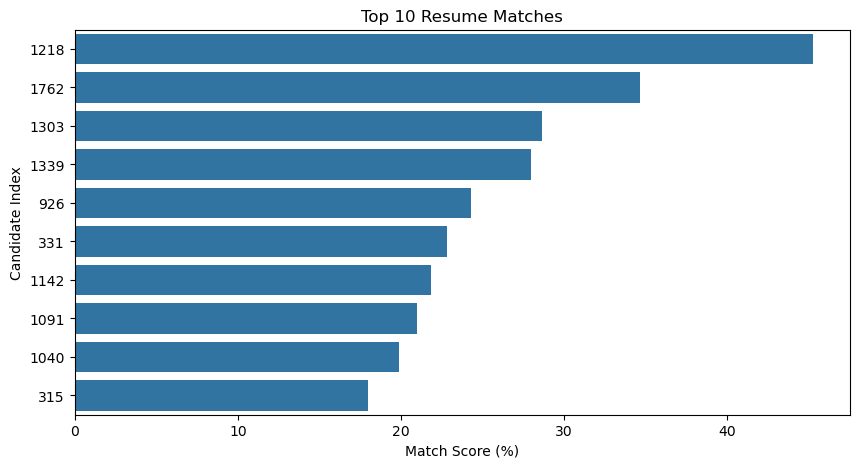

In [81]:
top10 = ranked_candidates.head(10)

plt.figure(figsize=(10,5))

sns.barplot(
    x='Match_Score',
    y=top10.index.astype(str),
    data=top10
)

plt.title('Top 10 Resume Matches')
plt.xlabel('Match Score (%)')
plt.ylabel('Candidate Index')

plt.show()

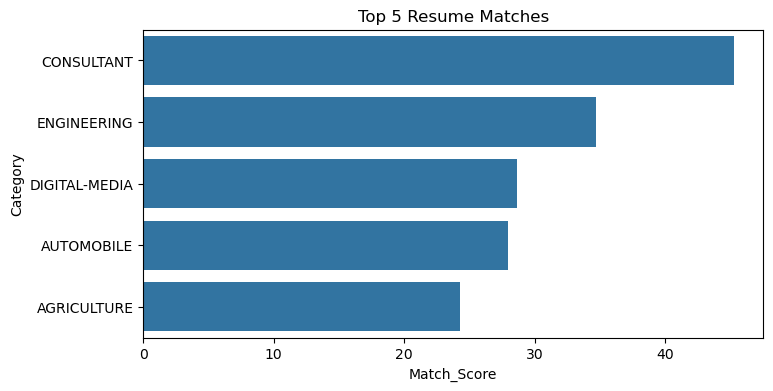

In [82]:
top5 = ranked_candidates.head(5)

plt.figure(figsize=(8,4))

sns.barplot(
    data=top5,
    x='Match_Score',
    y='Category'
)

plt.title('Top 5 Resume Matches')
plt.show()

## Skill Gap Analysis

In [83]:
required_skills = set(jd_skills)

candidate_skills = set(
    ranked_candidates.iloc[0]['Skills']
)


matched_skills = list(
    required_skills.intersection(candidate_skills)
)

missing_skills = list(
    required_skills - candidate_skills
)

print("Matched Skills:")
print(matched_skills)

print("\nMissing Skills:")
print(missing_skills)

Matched Skills:
['machine learning', 'data analysis', 'data visualization', 'sql', 'python']

Missing Skills:
['numpy', 'statistics', 'power bi', 'scikit-learn', 'pandas']


## Matched Skills vs Missing Skills

### Observation

The top-ranked candidate possesses several required skills; however, some skills are still missing. This analysis helps recruiters identify training needs and evaluate candidate readiness.

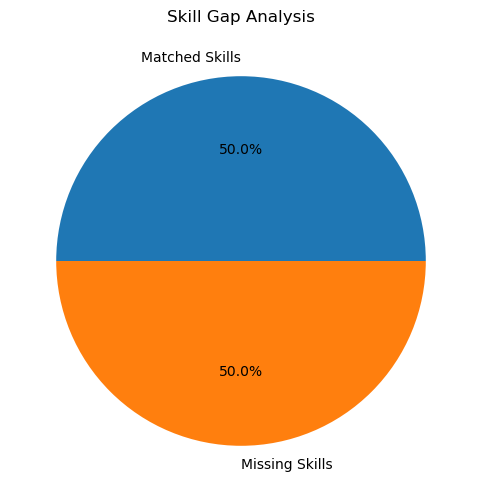

In [84]:
matched = len(matched_skills)

missing = len(missing_skills)

plt.figure(figsize=(6,6))

plt.pie(
    [matched, missing],
    labels=['Matched Skills','Missing Skills'],
    autopct='%1.1f%%'
)

plt.title('Skill Gap Analysis')

plt.show()

In [85]:
skill_gap_df = pd.DataFrame({

    'Matched Skills': pd.Series(matched_skills),
    'Missing Skills': pd.Series(missing_skills)

})

skill_gap_df

,Matched Skills,Missing Skills
0,machine learning,numpy
1,data analysis,statistics
2,data visualization,power bi
3,sql,scikit-learn
4,python,pandas


## Average Match Score by Resume Category

In [86]:
category_scores = (
    df.groupby('Category')['Match_Score']
    .mean()
    .sort_values(ascending=False)
)

print(category_scores)

Category
INFORMATION-TECHNOLOGY    4.367768
ENGINEERING               3.539914
AUTOMOBILE                3.365197
CONSULTANT                3.140864
AGRICULTURE               2.941527
HEALTHCARE                2.524969
TEACHER                   2.495082
BANKING                   2.488287
FINANCE                   2.382909
AVIATION                  2.325613
ACCOUNTANT                2.256938
DIGITAL-MEDIA             2.220314
BPO                       2.184541
ADVOCATE                  2.090815
ARTS                      2.084210
DESIGNER                  2.016215
HR                        1.963863
BUSINESS-DEVELOPMENT      1.766487
APPAREL                   1.714219
SALES                     1.659550
CONSTRUCTION              1.612985
FITNESS                   1.450410
PUBLIC-RELATIONS          1.415330
CHEF                      0.951035
Name: Match_Score, dtype: float64


### Observation

Most resumes achieve moderate similarity scores, while only a small number of candidates closely match the job description. This helps recruiters focus on the most relevant applicants.

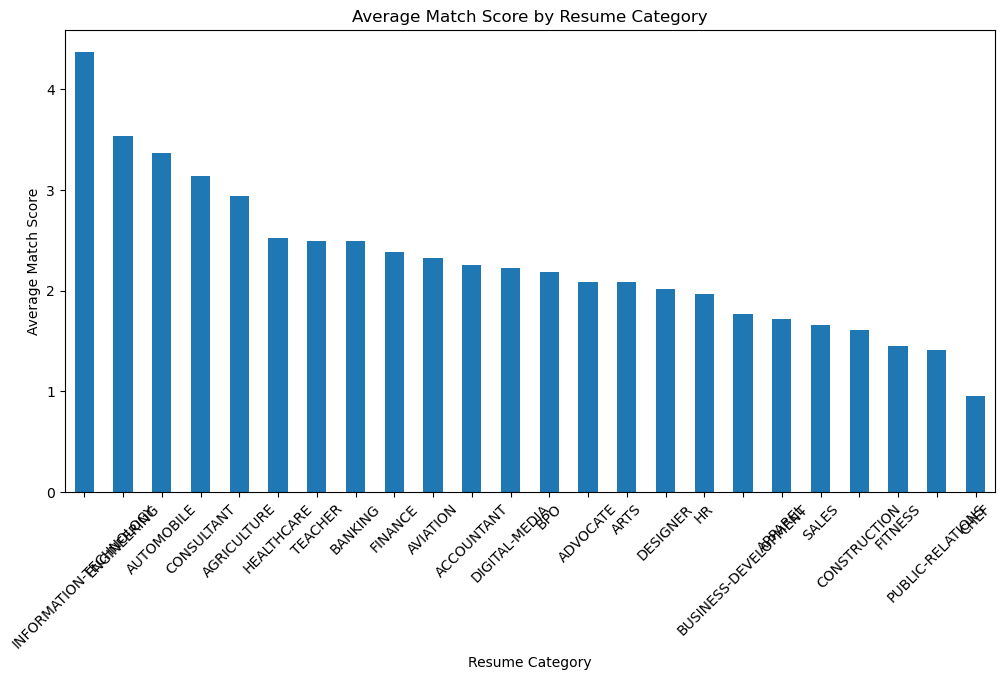

In [87]:
plt.figure(figsize=(12,6))

category_scores.plot(
    kind='bar'
)

plt.title(
    'Average Match Score by Resume Category'
)

plt.xlabel('Resume Category')

plt.ylabel('Average Match Score')

plt.xticks(rotation=45)

plt.show()

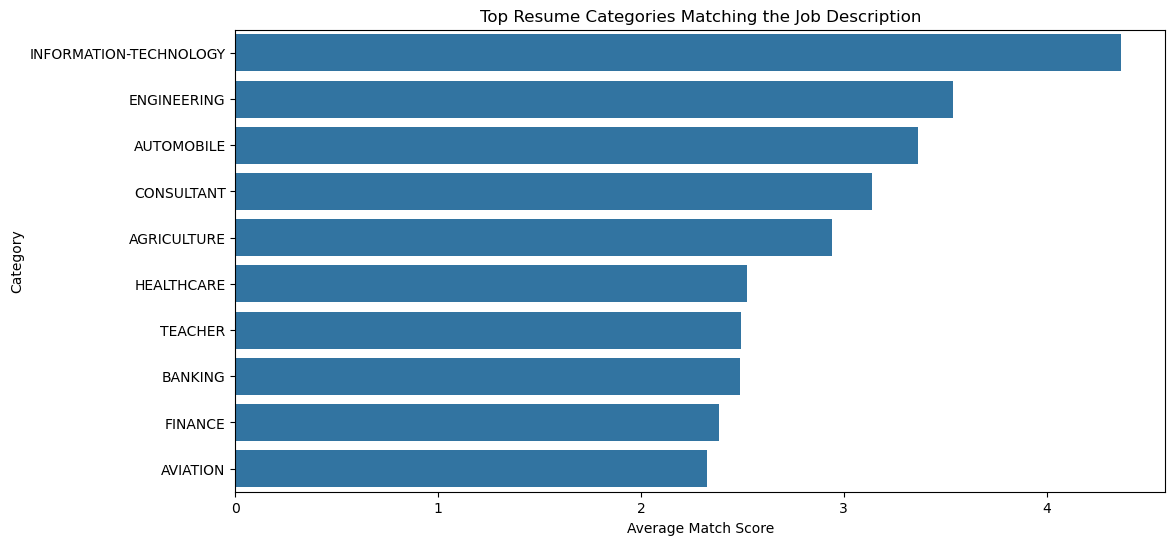

In [88]:
top_categories = (
    df.groupby('Category')['Match_Score']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12,6))

sns.barplot(
    x=top_categories.values,
    y=top_categories.index
)

plt.title(
    'Top Resume Categories Matching the Job Description'
)

plt.xlabel('Average Match Score')

plt.ylabel('Category')

plt.show()

In [89]:
ranked_candidates[
    ['Category','Match_Score','Skills']
].head(10)

,Category,Match_Score,Skills
1218,CONSULTANT,45.250064,"[python, sql, machine learning, data analysis,..."
1762,ENGINEERING,34.675666,"[python, sql, machine learning, pandas, tablea..."
1303,DIGITAL-MEDIA,28.673349,"[python, sql, power bi, tableau, excel, java, ..."
1339,AUTOMOBILE,27.941748,"[python, sql, pandas, numpy, tableau, excel, s..."
926,AGRICULTURE,24.272995,"[python, sql, tensorflow, keras, pandas, table..."
331,INFORMATION-TECHNOLOGY,22.817171,"[python, sql, tableau, excel, data analysis, a..."
1142,CONSULTANT,21.809397,"[sql, tableau, excel, java, html, javascript]"
1091,SALES,20.968286,"[sql, tableau, excel, java, html, css, javascr..."
1040,SALES,19.884647,"[machine learning, tableau, excel, statistics,..."
315,INFORMATION-TECHNOLOGY,17.989700,"[python, sql, excel, statistics, java]"


In [90]:
best_candidate = ranked_candidates.iloc[0]

print("Category:")
print(best_candidate['Category'])

print("\nMatch Score:")
print(round(best_candidate['Match_Score'],2))

print("\nSkills:")
print(best_candidate['Skills'])

Category:
CONSULTANT

Match Score:
45.25

Skills:
['python', 'sql', 'machine learning', 'data analysis', 'data visualization', 'java', 'azure', 'javascript', 'mysql']


## Skill Gap Analysis

In [96]:
def compute_skill_gap(candidate_skills):

    return [s for s in jd_skills if s not in candidate_skills]

ranked_candidates = ranked_candidates.copy()
ranked_candidates['Missing_Skills'] = ranked_candidates['Skills'].apply(compute_skill_gap)
ranked_candidates['Skills_Match_Count'] = ranked_candidates['Skills'].apply(
    lambda s: len([x for x in jd_skills if x in s])
)
ranked_candidates['Skills_Gap_Count'] = ranked_candidates['Missing_Skills'].apply(len)

print('Top 5 Candidates — Skill Gap Summary')
print('='*60)
for i, (_, row) in enumerate(ranked_candidates.head(5).iterrows()):
    print(f"\nRank {i+1} | Category: {row['Category']} | Match Score: {row['Match_Score']:.2f}")
    print(f"Matched Skills ({row['Skills_Match_Count']}): {[s for s in jd_skills if s in row['Skills']]}")
    print(f"Missing Skills ({row['Skills_Gap_Count']}): {row['Missing_Skills']}")

Top 5 Candidates — Skill Gap Summary

Rank 1 | Category: CONSULTANT | Match Score: 45.25
Matched Skills (5): ['python', 'sql', 'machine learning', 'data analysis', 'data visualization']
Missing Skills (5): ['pandas', 'numpy', 'scikit-learn', 'power bi', 'statistics']

Rank 2 | Category: ENGINEERING | Match Score: 34.68
Matched Skills (7): ['python', 'sql', 'machine learning', 'pandas', 'statistics', 'data analysis', 'data visualization']
Missing Skills (3): ['numpy', 'scikit-learn', 'power bi']

Rank 3 | Category: DIGITAL-MEDIA | Match Score: 28.67
Matched Skills (3): ['python', 'sql', 'power bi']
Missing Skills (7): ['machine learning', 'pandas', 'numpy', 'scikit-learn', 'statistics', 'data analysis', 'data visualization']

Rank 4 | Category: AUTOMOBILE | Match Score: 27.94
Matched Skills (7): ['python', 'sql', 'pandas', 'numpy', 'statistics', 'data analysis', 'data visualization']
Missing Skills (3): ['machine learning', 'scikit-learn', 'power bi']

Rank 5 | Category: AGRICULTURE | M

## Skill Gap Visualization --Top 10 candidates

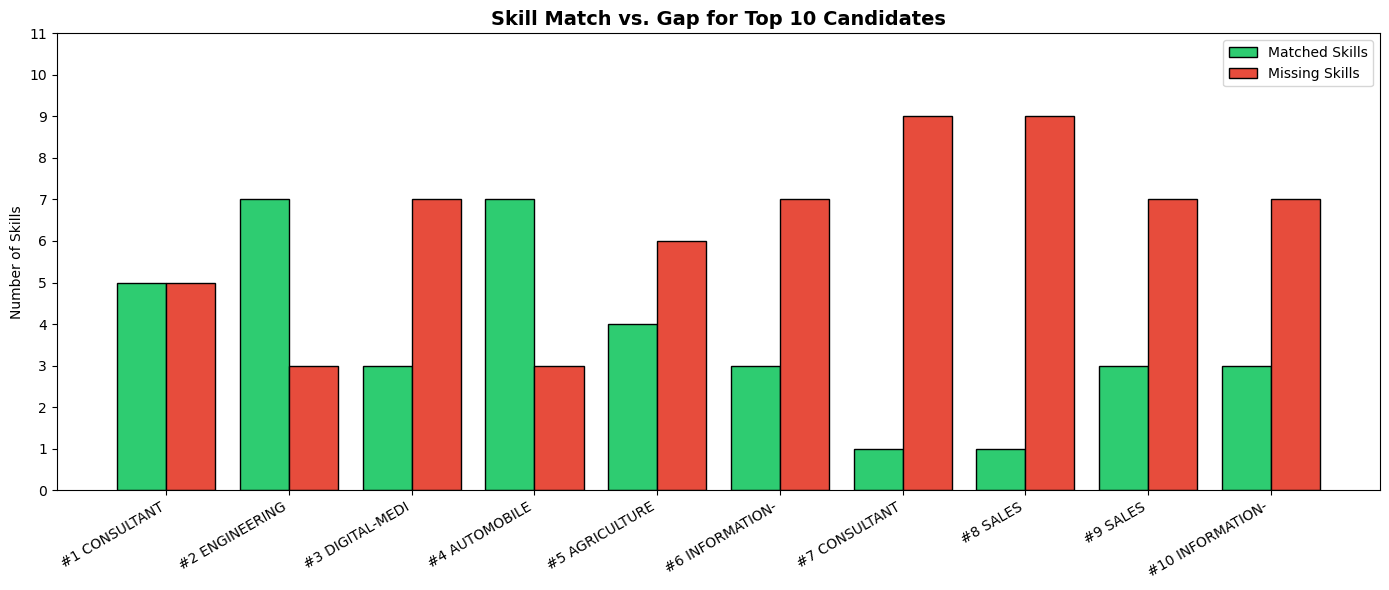


Required skills for the role (10 total): ['python', 'sql', 'machine learning', 'pandas', 'numpy', 'scikit-learn', 'power bi', 'statistics', 'data analysis', 'data visualization']


In [97]:
import matplotlib.pyplot as plt
import numpy as np

top10 = ranked_candidates.head(10).reset_index(drop=True)
labels = [f"#{i+1} {row['Category'][:12]}" for i, row in top10.iterrows()]

x = np.arange(len(labels))
width = 0.4

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, top10['Skills_Match_Count'], width,
               label='Matched Skills', color='#2ecc71', edgecolor='black')
bars2 = ax.bar(x + width/2, top10['Skills_Gap_Count'], width,
               label='Missing Skills', color='#e74c3c', edgecolor='black')

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=10)
ax.set_ylabel('Number of Skills')
ax.set_title('Skill Match vs. Gap for Top 10 Candidates', fontsize=14, fontweight='bold')
ax.legend()
ax.set_yticks(range(0, int(len(jd_skills))+2))
plt.tight_layout()
plt.show()

print(f'\nRequired skills for the role ({len(jd_skills)} total): {jd_skills}')

## Business Insight

- Candidates are ranked based on similarity between their resumes and the job description.
- Skill gap analysis identifies missing competencies required for the role.
- Categories with higher average match scores are better aligned with the target Data Scientist position.
- Recruiters can prioritize high-scoring candidates and focus training efforts on missing skills.

## Conclusion

A Resume Screening and Ranking System was developed using Natural Language Processing techniques.
Resume texts were cleaned and processed to extract relevant skills. Candidate resumes were compared with a Data Scientist job description using TF-IDF vectorization and cosine similarity.
Candidates were ranked according to their match scores, and skill gap analysis was performed to identify missing competencies.
The developed system can help recruiters shortlist candidates efficiently, reduce manual effort, and support data-driven hiring decisions.

In [92]:
ranked_candidates.to_csv(
    "ranked_candidates.csv",
    index=False
)

In [95]:
print("Project Completed Successfully")
print("Total Resumes Processed:", len(df))
print("Top Candidate Match Score:",
      round(ranked_candidates.iloc[0]['Match_Score'],2))

Project Completed Successfully
Total Resumes Processed: 2484
Top Candidate Match Score: 45.25
